In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn 

In [66]:
# Q1: Load the Iris dataset using sklearn.datasets.load_iris() and print feature_names , target_names , and the shape of data .
data = sklearn.datasets.load_iris()
print(f"feature names: {data['feature_names']}")
print(f"target names: {data['target_names']}")
data.data.shape

feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target names: ['setosa' 'versicolor' 'virginica']


(150, 4)

### Q2: Provide a short written answer: What type of problem is this (classification/regression)? Why? Write your answer in a Markdown cell below.
This problem is classification. Because we use their similarity and patterns that identify the object

In [67]:
# Q3: Show the first five rows of the data as a pandas DataFrame with column names from feature_names.
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [68]:
# Q4: Report class distribution (counts for each species)
dist = pd.Series(data['target_names'][data['target']])
print(dist.value_counts())

setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


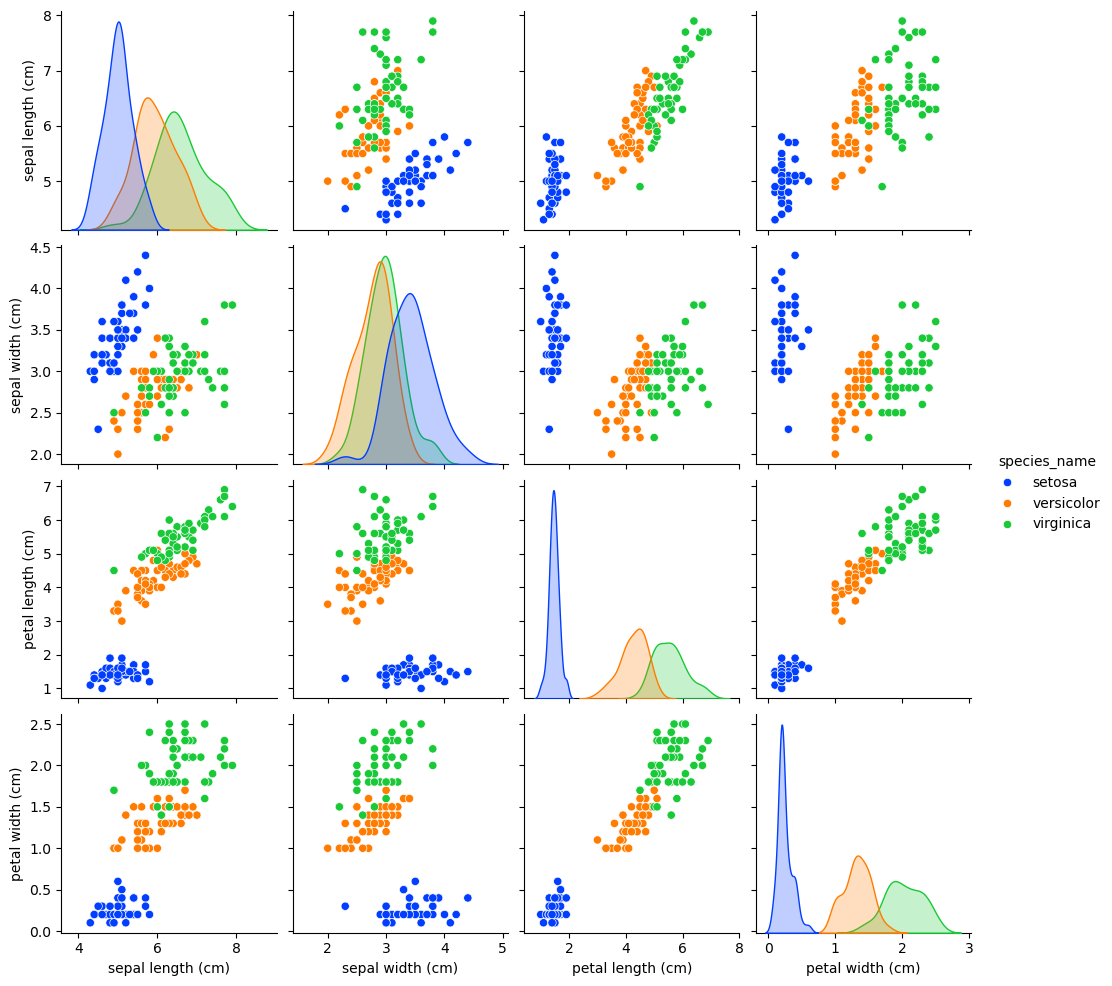

In [69]:
# Q5: Create a pair plot (scatter plot matrix) for the four features using matplotlib. Color points by species.
df['species_name'] = pd.Series(data.target).map(dict(enumerate(data.target_names)))

sns.pairplot(df, vars=data.feature_names, hue='species_name', palette='bright')
plt.show()

### Q6: Based on your plot, which two features appear most useful to separate the classes? Explain in one short sentence.
Most useful features are - (sepal length and petal width) and (petal width and petal length), because here we can see that by this features our dates are divided clearly.

In [70]:
# Q7: Split the data into train/test sets (75% train, 25% test). Use stratify=target and random_state=42 . Print shapes.
from sklearn.model_selection import train_test_split
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,   
    stratify=y,       
    random_state=42    
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (112, 4)
X_test shape: (38, 4)
y_train shape: (112,)
y_test shape: (38,)


In [71]:
# Q8: Train a KNeighborsClassifier with n_neighbors=3 . Fit on training data and report test accuracy.
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
np.mean(y_pred == y_test)

0.9736842105263158

In [72]:
# Q9: Compare accuracy for n_neighbors = 1, 3, 5. Report which k gives best accuracy and why (short sentence).
knn1 = KNeighborsClassifier(n_neighbors=1)
knn5 = KNeighborsClassifier(n_neighbors=5)

knn1.fit(X_train, y_train)
y_pred1 = knn1.predict(X_test)
knn5.fit(X_train, y_train)
y_pred5 = knn5.predict(X_test)

print(np.mean(y_pred1 == y_test))
print(np.mean(y_pred5 == y_test))

0.9473684210526315
0.9736842105263158


In [73]:
# Q10: Use your trained KNeighborsClassifier (use k=3) to predict the class of a new
# sample with features: [5.0, 2.9, 1.0, 0.2] . Show predicted class name.
x = np.array([[5.0, 2.9, 1.0, 0.2]])
y_pred = knn.predict(x)
y_pred_name = data.target_names[y_pred]
print(y_pred_name)

['setosa']
